In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2

In [3]:
# Load dataset
df = pd.read_csv("secondary_data.csv", sep=';')


In [17]:
numeric_cols = ["cap-diameter", "stem-height", "stem-width"]
categorical_cols = [col for col in df.columns if col not in numeric_cols]


In [7]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [11]:
X = df.drop(columns=["class"])
y = df["class"]

selector = SelectKBest(chi2, k=10)
selector.fit(X, y)
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)


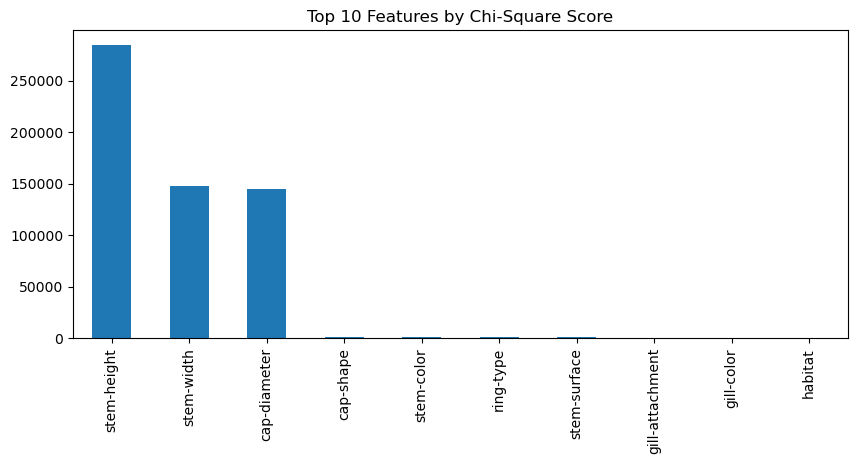

In [13]:
scores.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Features by Chi-Square Score")
plt.show()

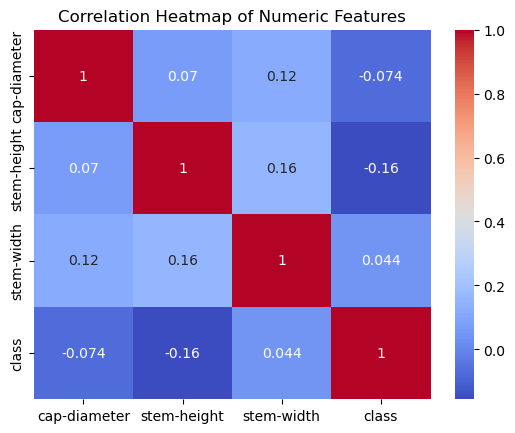

In [19]:
sns.heatmap(df[numeric_cols + ["class"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()